# R2 — Baseline run: outputs and evidence

Visual record of the R2 baseline run (2 epochs, 50 train batches, `configs/baseline.yaml`),
plus the evidence behind one claim worth flagging before R3:

> **The trained model reports ~5.4° mean angular error, but a constant predictor that
> ignores the image entirely scores ~4.5° on the same data.** The error number therefore
> cannot, by itself, tell a working model apart from a broken one on this dataset.

This notebook shows the current outputs and the plots that support that claim. It draws
no pass/fail verdicts and changes nothing about the model — it is a record for R3.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as Fnn

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

from evedataset import EveBundle

from eyenet.dataset import EyeGazeDataModule
from eyenet.lightning_module import GazeEstimationModule
from eyenet.losses import angular_error_degrees

RUN = REPO / "runs" / "baseline"
BUNDLE_DIR = REPO.parent / "eve_shared" / "EveDataset" / "bundle"
CROPS_ROOT = REPO.parent / "eve_shared" / "EveDataset" / "eve_out"
torch.manual_seed(0)
print("run dir:", RUN, "| exists:", RUN.exists())

run dir: c:\Users\ulloa\Miooooo\Master\thesis\Projects\EyeNet Pipeline\runs\baseline | exists: True


## 1. Training curves

`train/loss` is logged `on_step` **and** `on_epoch`, so Lightning writes
`train/loss_step` / `train/loss_epoch` — there is no bare `train/loss` column.

c:\Users\ulloa\Miooooo\Master\thesis\Projects\EyeNet Pipeline\runs\baseline\csv\version_0\metrics.csv
columns: ['epoch', 'step', 'train/loss_epoch', 'train/loss_step', 'val/angular_error_deg', 'val/loss']


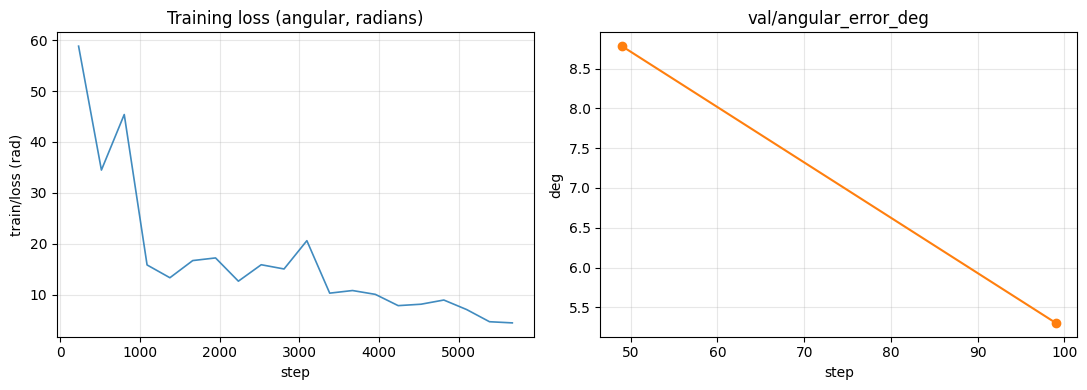


NaNs in train/loss : 0
loss  first -> last: 58.811 -> 4.467 rad
val angular error  : 8.78 -> 5.30 deg


In [12]:
metrics_path = sorted(RUN.glob("csv/version_*/metrics.csv"))[-1]
df = pd.read_csv(metrics_path)
step_loss = df[["step", "train/loss_step"]].dropna()*(180/np.pi)
val_deg = df[["step", "val/angular_error_deg"]].dropna()
print(metrics_path)
print("columns:", list(df.columns))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(step_loss["step"], step_loss["train/loss_step"], lw=1.2, alpha=0.85)
axes[0].set(xlabel="step", ylabel="train/loss (rad)", title="Training loss (angular, radians)")
axes[0].grid(alpha=0.3)
axes[1].plot(val_deg["step"], val_deg["val/angular_error_deg"], "o-", color="tab:orange")
axes[1].set(xlabel="step", ylabel="deg", title="val/angular_error_deg")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nNaNs in train/loss : {int(step_loss['train/loss_step'].isna().sum())}")
print(f"loss  first -> last: {step_loss['train/loss_step'].iloc[0]:.3f} -> "
      f"{step_loss['train/loss_step'].iloc[-1]:.3f} rad")
print(f"val angular error  : {' -> '.join(f'{v:.2f}' for v in val_deg['val/angular_error_deg'])} deg")

## 2. Collect the model's current outputs over real val data

In [3]:
bundle = EveBundle.load(BUNDLE_DIR)
dm = EyeGazeDataModule(bundle, CROPS_ROOT, {"seed": 42, "val_fraction": 0.2}, batch_size=32, num_workers=0)
dm.setup()
trained = GazeEstimationModule.load_from_checkpoint(
    RUN / "checkpoints" / "last.ckpt", map_location="cpu").eval()

img_l, tgt_l, pred_l, patch_l, frame_l = [], [], [], [], []
with torch.no_grad():
    for i, (images, targets, exp_keys, frames, patches) in enumerate(dm.val_dataloader()):
        if i >= 8:
            break
        img_l.append(images); tgt_l.append(targets); pred_l.append(trained(images))
        patch_l += list(patches); frame_l += [int(f) for f in frames]

images, targets, preds = torch.cat(img_l), torch.cat(tgt_l), torch.cat(pred_l)
trained_deg = angular_error_degrees(preds, targets)
print(f"val split : {len(dm.val_ds)} samples | pooled {len(targets)} for inspection")
print(f"||pred||  : {preds.norm(dim=1).min():.6f} .. {preds.norm(dim=1).max():.6f}  (unit-norm holds on real data)")
print(f"mean angular error : {trained_deg.mean():.2f} deg")

val split : 45482 samples | pooled 256 for inspection
||pred||  : 1.000000 .. 1.000000  (unit-norm holds on real data)
mean angular error : 5.37 deg


## 3. Evidence #1 — the ground truth barely varies

Everyone is looking at a screen, so EVE's gaze targets occupy a very narrow cone. This
is the root of the problem: when the labels span only a few degrees, *any* constant
prediction near the centre of that cone is already within a few degrees of every label.

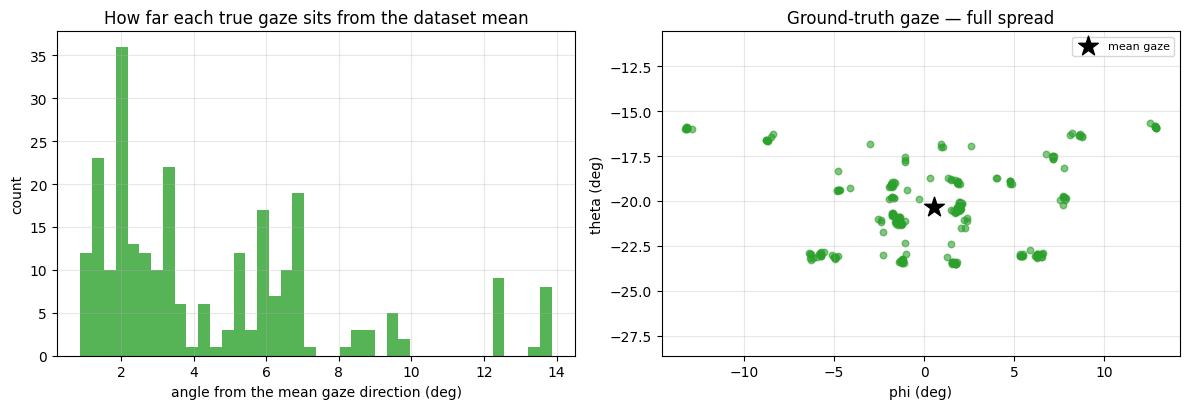

ground-truth angular spread about its own mean : 4.52 deg
theta (vertical)   sd : 2.34 deg   range [-23.5, -15.6]
phi   (horizontal) sd : 5.36 deg   range [-13.3, 12.9]


In [4]:
def unit_to_spherical(g):
    """Inverse of spherical_to_unit (MPIIGaze): theta = arcsin(-g_y), phi = arctan2(-g_x, -g_z)."""
    g = np.asarray(g, dtype=np.float64)
    return (np.degrees(np.arcsin(np.clip(-g[..., 1], -1.0, 1.0))),
            np.degrees(np.arctan2(-g[..., 0], -g[..., 2])))


def self_spread_deg(v):
    m = Fnn.normalize(v.mean(0, keepdim=True), dim=1).repeat(len(v), 1)
    return angular_error_degrees(m, v)


t_theta, t_phi = unit_to_spherical(targets.numpy())
p_theta, p_phi = unit_to_spherical(preds.numpy())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(self_spread_deg(targets).numpy(), bins=40, color="tab:green", alpha=0.8)
axes[0].set(xlabel="angle from the mean gaze direction (deg)", ylabel="count",
            title="How far each true gaze sits from the dataset mean")
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(t_phi, t_theta, s=22, alpha=0.6, color="tab:green")
axes[1].scatter([t_phi.mean()], [t_theta.mean()], s=220, marker="*", color="black",
                zorder=5, label="mean gaze")
axes[1].set(xlabel="phi (deg)", ylabel="theta (deg)", title="Ground-truth gaze — full spread")
axes[1].set_aspect("equal", adjustable="datalim")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ground-truth angular spread about its own mean : {self_spread_deg(targets).mean():.2f} deg")
print(f"theta (vertical)   sd : {t_theta.std():.2f} deg   range [{t_theta.min():.1f}, {t_theta.max():.1f}]")
print(f"phi   (horizontal) sd : {t_phi.std():.2f} deg   range [{t_phi.min():.1f}, {t_phi.max():.1f}]")

## 4. Evidence #2 — the trained model does not beat a constant predictor

Three reference predictors on the same 256 val samples:

- **uniform random** unit vectors — this is the ≈90° figure validation.md assumed an
  untrained net would produce;
- **constant mean-gaze** — always emit the dataset's mean gaze, ignore the image entirely;
- **trained model**.

Note the ≈90° reference is real but useless here: it describes uniform vectors, and the
gap between 90° and 5° is *the narrow label cone*, not model skill.

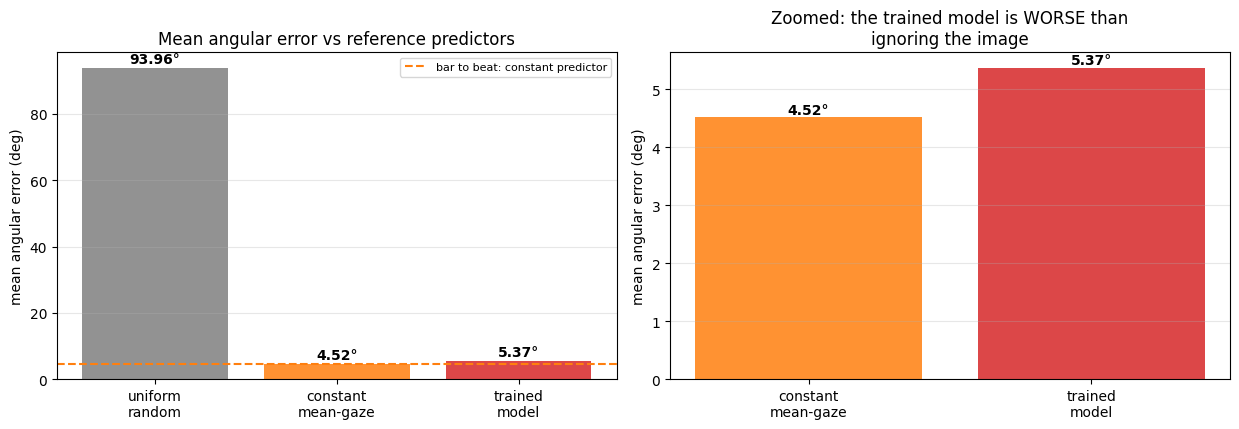

uniform random        :  93.96 deg   <- what '~90 deg' actually describes
constant mean-gaze    :   4.52 deg   <- ignores the image completely
trained model         :   5.37 deg   <- WORSE by 0.86 deg


In [5]:
rng = torch.Generator().manual_seed(0)
uniform = Fnn.normalize(torch.randn(len(targets), 3, generator=rng), dim=1)
mean_gaze = Fnn.normalize(targets.mean(0, keepdim=True), dim=1).repeat(len(targets), 1)

uniform_deg = angular_error_degrees(uniform, targets)
mean_gaze_deg = angular_error_degrees(mean_gaze, targets)

names = ["uniform\nrandom", "constant\nmean-gaze", "trained\nmodel"]
vals = [uniform_deg.mean().item(), mean_gaze_deg.mean().item(), trained_deg.mean().item()]
colors = ["tab:gray", "tab:orange", "tab:red"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
bars = axes[0].bar(names, vals, color=colors, alpha=0.85)
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.2f}°", ha="center", fontweight="bold")
axes[0].axhline(mean_gaze_deg.mean().item(), ls="--", c="tab:orange", lw=1.5,
                label="bar to beat: constant predictor")
axes[0].set(ylabel="mean angular error (deg)", title="Mean angular error vs reference predictors")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names[1:], vals[1:], color=colors[1:], alpha=0.85)
for i, v in enumerate(vals[1:]):
    axes[1].text(i, v + 0.06, f"{v:.2f}°", ha="center", fontweight="bold")
axes[1].set(ylabel="mean angular error (deg)",
            title="Zoomed: the trained model is WORSE than\nignoring the image")
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"uniform random        : {uniform_deg.mean():6.2f} deg   <- what '~90 deg' actually describes")
print(f"constant mean-gaze    : {mean_gaze_deg.mean():6.2f} deg   <- ignores the image completely")
print(f"trained model         : {trained_deg.mean():6.2f} deg   <- WORSE by "
      f"{trained_deg.mean() - mean_gaze_deg.mean():.2f} deg")

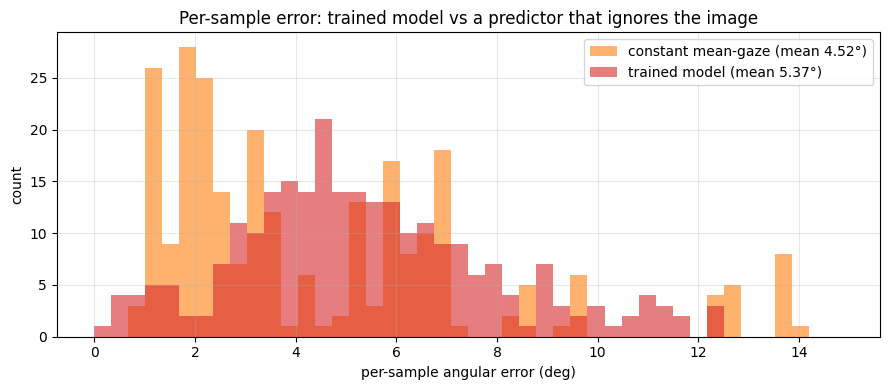

In [6]:
# Per-sample error distributions, not just the means.
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, max(trained_deg.max().item(), mean_gaze_deg.max().item()) + 1, 45)
ax.hist(mean_gaze_deg.numpy(), bins=bins, alpha=0.6, label=f"constant mean-gaze (mean {mean_gaze_deg.mean():.2f}°)",
        color="tab:orange")
ax.hist(trained_deg.numpy(), bins=bins, alpha=0.6, label=f"trained model (mean {trained_deg.mean():.2f}°)",
        color="tab:red")
ax.set(xlabel="per-sample angular error (deg)", ylabel="count",
       title="Per-sample error: trained model vs a predictor that ignores the image")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Evidence #3 — what the model *did* learn: phi yes, theta no

This is the plot that separates "learned the mapping" from "learned the mean", which
section 4 cannot. Per-sample, does the prediction move **with its own label**?

- a model that learned the mapping → points along `y = x`;
- a model emitting the mean → a flat horizontal band, `r ≈ 0`;
- an F-FLIP break → points along `y = -x` on phi, `r` strongly negative.

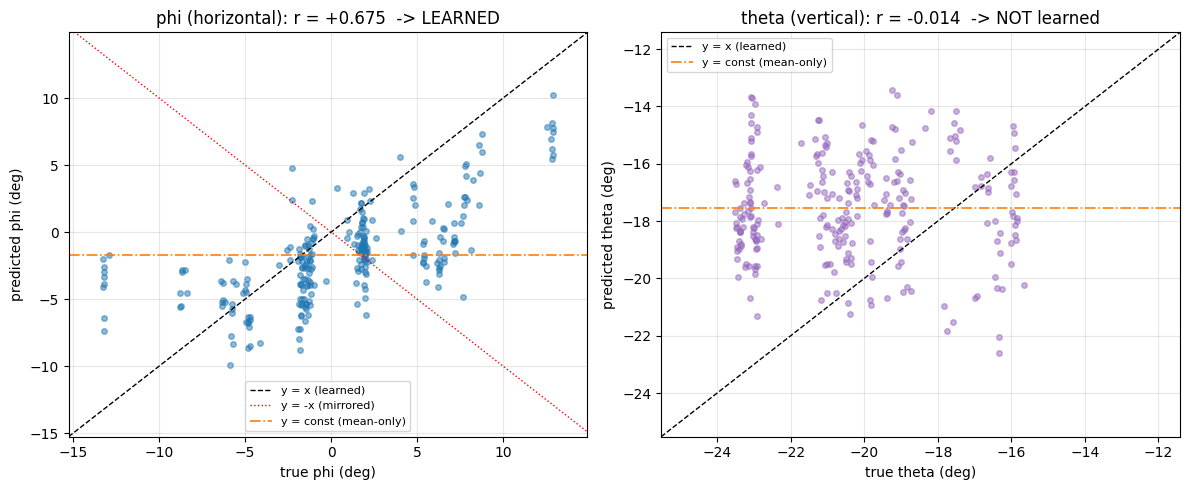

phi   (horizontal) r = +0.675  -- tracks ground truth: the image->label path works
theta (vertical)   r = -0.014  -- flat band: the model emits ~its own mean theta


In [7]:
r_theta = np.corrcoef(t_theta, p_theta)[0, 1]
r_phi = np.corrcoef(t_phi, p_phi)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lims = [min(t_phi.min(), p_phi.min()) - 2, max(t_phi.max(), p_phi.max()) + 2]
axes[0].scatter(t_phi, p_phi, s=16, alpha=0.5, color="tab:blue")
axes[0].plot(lims, lims, "k--", lw=1, label="y = x (learned)")
axes[0].plot(lims, [-v for v in lims], "r:", lw=1, label="y = -x (mirrored)")
axes[0].axhline(p_phi.mean(), color="tab:orange", lw=1.2, ls="-.", label="y = const (mean-only)")
axes[0].set(xlabel="true phi (deg)", ylabel="predicted phi (deg)", xlim=lims, ylim=lims,
            title=f"phi (horizontal): r = {r_phi:+.3f}  -> LEARNED")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

lims = [min(t_theta.min(), p_theta.min()) - 2, max(t_theta.max(), p_theta.max()) + 2]
axes[1].scatter(t_theta, p_theta, s=16, alpha=0.5, color="tab:purple")
axes[1].plot(lims, lims, "k--", lw=1, label="y = x (learned)")
axes[1].axhline(p_theta.mean(), color="tab:orange", lw=1.2, ls="-.", label="y = const (mean-only)")
axes[1].set(xlabel="true theta (deg)", ylabel="predicted theta (deg)", xlim=lims, ylim=lims,
            title=f"theta (vertical): r = {r_theta:+.3f}  -> NOT learned")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"phi   (horizontal) r = {r_phi:+.3f}  -- tracks ground truth: the image->label path works")
print(f"theta (vertical)   r = {r_theta:+.3f}  -- flat band: the model emits ~its own mean theta")

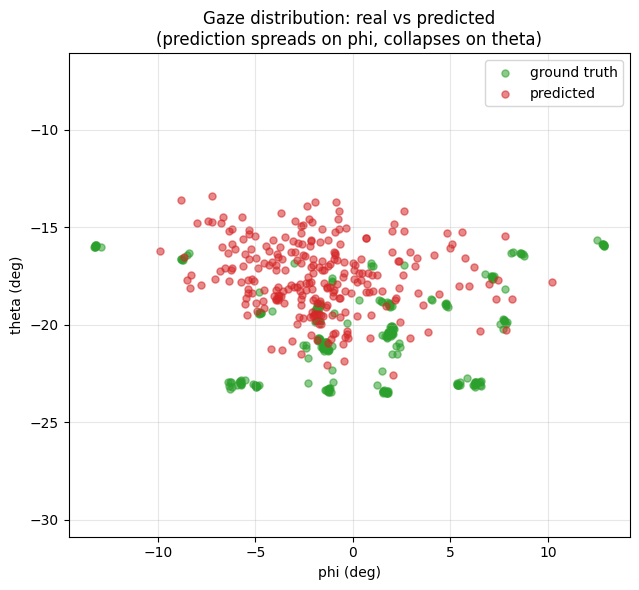

             theta sd     phi sd
truth            2.34       5.36
pred             1.80       3.46


In [8]:
# The two clouds overlaid: the prediction cloud is real but narrower than the truth,
# and it is squashed along theta -- the visual form of r_theta ~ 0.
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(t_phi, t_theta, s=26, alpha=0.55, label="ground truth", color="tab:green")
ax.scatter(p_phi, p_theta, s=26, alpha=0.55, label="predicted", color="tab:red")
ax.set(xlabel="phi (deg)", ylabel="theta (deg)",
       title="Gaze distribution: real vs predicted\n(prediction spreads on phi, collapses on theta)")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'':10s} {'theta sd':>10s} {'phi sd':>10s}")
print(f"{'truth':10s} {t_theta.std():10.2f} {t_phi.std():10.2f}")
print(f"{'pred':10s} {p_theta.std():10.2f} {p_phi.std():10.2f}")

## 6. Sample crops — ground truth (green) vs prediction (red)

Systematic mirroring would show as red arrows consistently x-flipped from green.

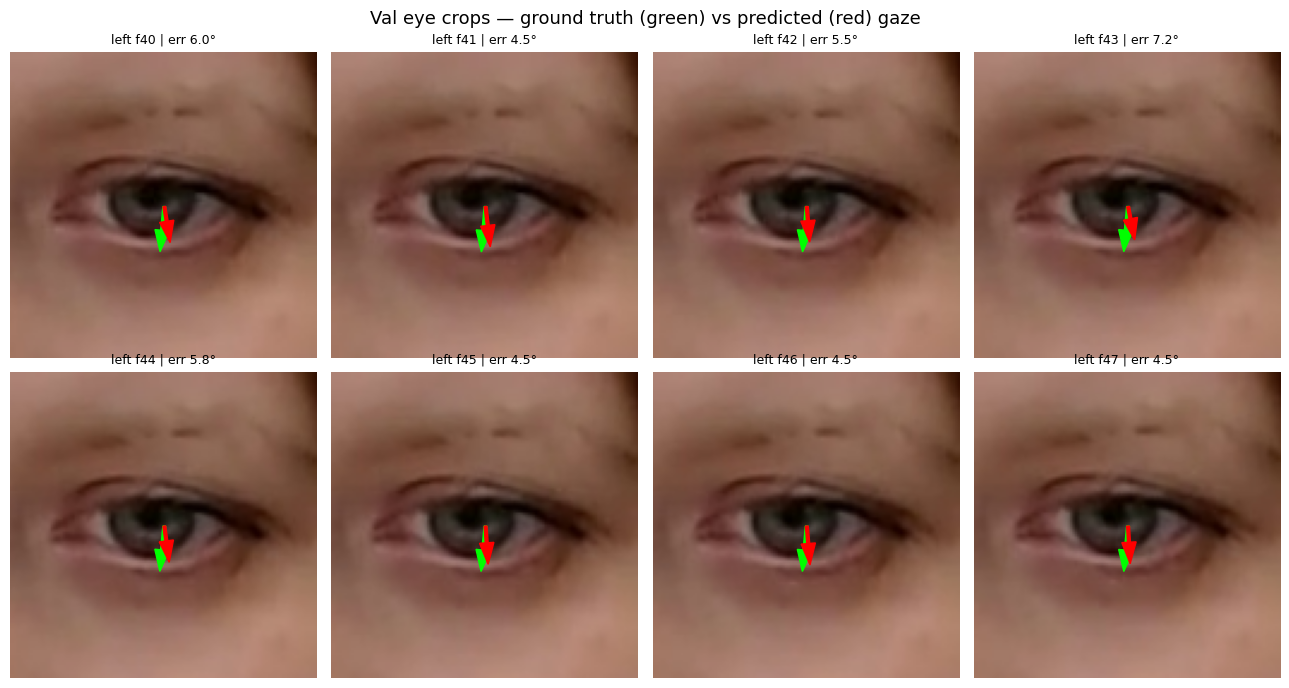

as-is     :   5.37 deg
x-negated :   7.59 deg
(x-negated being worse is consistent with the F-FLIP convention being intact)


In [9]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])


def to_display(tensor):
    img = tensor.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)


def draw_arrow(ax, vec, color, scale=55.0):
    """Project the gaze vector's x/y from the patch centre. Image y grows downward."""
    ax.arrow(64, 64, float(vec[0]) * scale, float(vec[1]) * scale,
             color=color, width=1.2, head_width=6, length_includes_head=True)


fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(to_display(images[i]))
    draw_arrow(ax, targets[i], "lime")
    draw_arrow(ax, preds[i], "red")
    ax.set_title(f"{patch_l[i]} f{frame_l[i]} | err {trained_deg[i]:.1f}°", fontsize=9)
    ax.axis("off")
fig.suptitle("Val eye crops — ground truth (green) vs predicted (red) gaze", fontsize=13)
plt.tight_layout()
plt.show()

mirrored = preds.clone()
mirrored[:, 0] *= -1
print(f"as-is     : {trained_deg.mean():6.2f} deg")
print(f"x-negated : {angular_error_degrees(mirrored, targets).mean():6.2f} deg")
print("(x-negated being worse is consistent with the F-FLIP convention being intact)")

## Summary of the evidence

**What the run shows works:** loss falls 1.03 → 0.08 rad with zero NaNs, checkpoints
round-trip, predictions stay unit-norm on real data, and `phi` correlation (r ≈ +0.68)
confirms gradients flow from real pixels to a real label — the image→label path is wired
correctly end to end. That is R2's actual deliverable, and it holds.

**What the plots flag for R3:**

1. **The angular-error number is not interpretable on its own here** (§3, §4). EVE's
   labels span ~4.5°, so a constant mean-gaze predictor scores ~4.5° — better than this
   subset model's ~5.4°. Reporting ~5° as if it were comparable to published 4–7°
   baselines would be wrong. **R3 should compute the mean-gaze predictor's score per split
   and treat it as the floor**, rather than using validation.md's ≈90° reference, which
   describes uniform-random vectors and is not a meaningful bar on this label distribution.
2. **`theta` (vertical gaze) is not learned** (§5): r ≈ 0, predictions form a flat band at
   their own mean, while `phi` tracks properly. Plausibly just the 2-epoch/50-batch subset,
   but it should be re-checked on the full-split run before any error number is quoted.

Neither finding is a defect in the R2 code — they are properties of the data and of the
deliberately tiny baseline run. They are recorded here so R3 starts from them.